In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import os

In [3]:
#Load Dataset
df= pd.read_csv("/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv"
)

In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
df.shape

(17966, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [7]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [8]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [10]:
categorical_columns = ["model", "transmission", "fuelType"]

for column in categorical_columns:
    df[column] = df[column].str.strip()

In [11]:
print("Models:")
print(sorted(df["model"].unique()))

print("\nTransmission types:")
print(sorted(df["transmission"].unique()))

print("\nFuel types:")
print(sorted(df["fuelType"].unique()))

Models:
['B-MAX', 'C-MAX', 'EcoSport', 'Edge', 'Escort', 'Fiesta', 'Focus', 'Fusion', 'Galaxy', 'Grand C-MAX', 'Grand Tourneo Connect', 'KA', 'Ka+', 'Kuga', 'Mondeo', 'Mustang', 'Puma', 'Ranger', 'S-MAX', 'Streetka', 'Tourneo Connect', 'Tourneo Custom', 'Transit Tourneo']

Transmission types:
['Automatic', 'Manual', 'Semi-Auto']

Fuel types:
['Diesel', 'Electric', 'Hybrid', 'Other', 'Petrol']


# ***Data Cleaning*** 

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 154


In [13]:
df = df.drop_duplicates()

In [14]:
print("Cars with year above 2025:", (df["year"] > 2025).sum())

Cars with year above 2025: 1


In [15]:
df = df[df["year"] <= 2025]

In [16]:
print("Cars with zero engine size:", (df["engineSize"] == 0).sum())

Cars with zero engine size: 51


In [17]:
df = df[df["engineSize"] > 0]

In [18]:
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("Invalid years:", (df["year"] > 2025).sum())
print("Zero engine sizes:", (df["engineSize"] == 0).sum())
print("Missing values:", df.isnull().sum().sum())

Shape: (17760, 9)
Duplicates: 0
Invalid years: 0
Zero engine sizes: 0
Missing values: 0


# EDA

In [19]:
df["model"].value_counts()

model
Fiesta                   6489
Focus                    4545
Kuga                     2207
EcoSport                 1119
C-MAX                     542
Ka+                       519
Mondeo                    511
B-MAX                     350
S-MAX                     294
Grand C-MAX               247
Galaxy                    227
Edge                      205
KA                        191
Puma                       78
Tourneo Custom             69
Grand Tourneo Connect      57
Mustang                    57
Tourneo Connect            32
Fusion                     16
Streetka                    2
Ranger                      1
Escort                      1
Transit Tourneo             1
Name: count, dtype: int64

In [20]:
df["transmission"].value_counts()

transmission
Manual       15336
Automatic     1349
Semi-Auto     1075
Name: count, dtype: int64

In [21]:
df["fuelType"].value_counts()

fuelType
Petrol      12035
Diesel       5701
Hybrid         21
Electric        2
Other           1
Name: count, dtype: int64

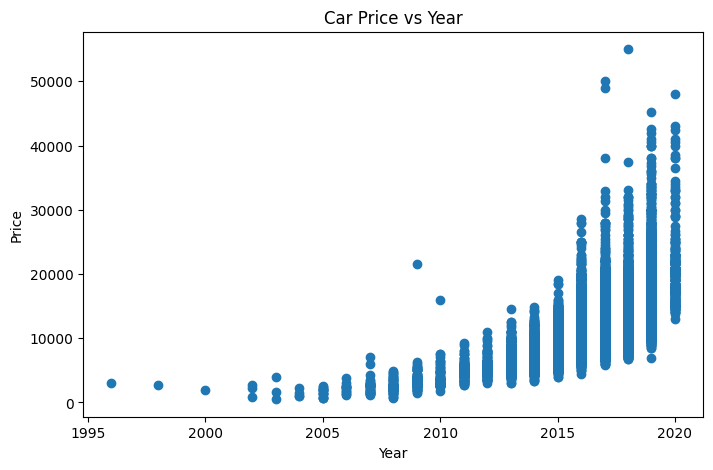

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(df["year"], df["price"])

plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Car Price vs Year")

plt.show()

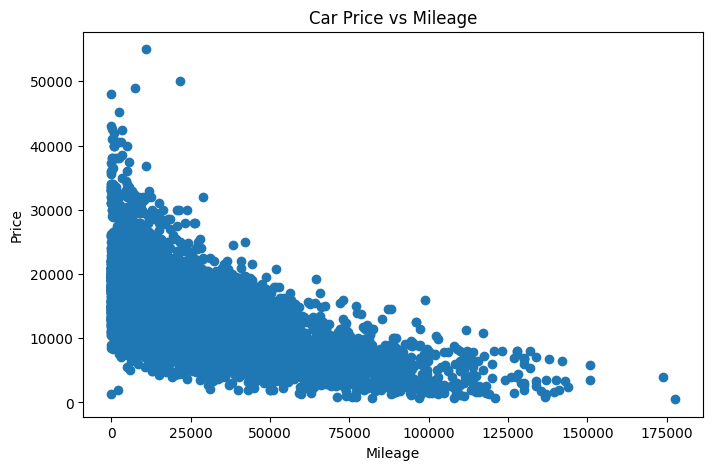

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(df["mileage"], df["price"])

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Car Price vs Mileage")

plt.show()

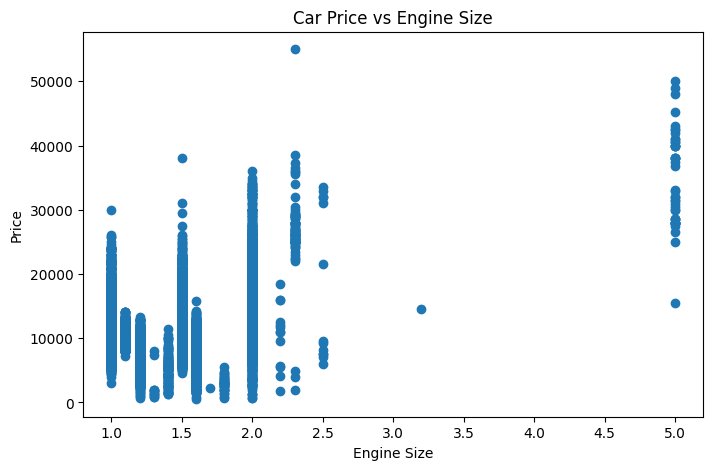

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(df["engineSize"], df["price"])

plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.title("Car Price vs Engine Size")

plt.show()

In [25]:
df.corr(numeric_only=True)

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.645553,-0.719459,0.298729,-0.019303,-0.139539
price,0.645553,1.000000,-0.530648,0.406303,-0.346463,0.416801
mileage,-0.719459,-0.530648,1.000000,-0.257229,0.117155,0.216255
tax,0.298729,0.406303,-0.257229,1.000000,-0.502518,0.187623
mpg,-0.019303,-0.346463,0.117155,-0.502518,1.000000,-0.267240
engineSize,-0.139539,0.416801,0.216255,0.187623,-0.267240,1.000000


# Train/Test Split

In [26]:
X = df.drop("price", axis=1)
y = df["price"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (14208, 8)
X_test: (3552, 8)
y_train: (14208,)
y_test: (3552,)


In [29]:
categorical_features = ["model", "transmission", "fuelType"]

numerical_features = ["year", "mileage", "tax", "mpg", "engineSize"]

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# Linear Regression Model (Baseline)

In [32]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [33]:
linear_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', LinearRegression())])

In [34]:
linear_pred = linear_model.predict(X_test)

In [35]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 1414.0646334157004
Linear Regression RMSE: 2001.4138344302803
Linear Regression R²: 0.8225437692413181


# Random Forest

In [36]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [37]:
rf_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [38]:
rf_pred = rf_model.predict(X_test)

In [39]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 885.8233794944498
Random Forest RMSE: 1343.0556079340606
Random Forest R²: 0.9200892057962771


# Check Overfitting

In [40]:
rf_train_pred = rf_model.predict(X_train)

train_r2 = r2_score(y_train, rf_train_pred)
test_r2 = r2_score(y_test, rf_pred)

train_mae = mean_absolute_error(y_train, rf_train_pred)
test_mae = mean_absolute_error(y_test, rf_pred)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

print("Training MAE:", train_mae)
print("Testing MAE:", test_mae)

Training R²: 0.9900334373686848
Testing R²: 0.9200892057962771
Training MAE: 324.9962686168312
Testing MAE: 885.8233794944498


# Hyperparameter tuning

In [41]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [42]:
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [44]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['model',
                                                                                'transmission',
                                                                                'fuelType'])])),
                                             ('model',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [45]:
print("Best parameters:")
print(random_search.best_params_)

Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 20}


In [46]:
print("Best CV MAE:", -random_search.best_score_)

Best CV MAE: 835.7889152679154


In [47]:
final_model = random_search.best_estimator_

In [48]:
final_pred = final_model.predict(X_test)

In [49]:
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print("Final Model MAE:", final_mae)
print("Final Model RMSE:", final_rmse)
print("Final Model R²:", final_r2)

Final Model MAE: 836.5849054309144
Final Model RMSE: 1269.5455890217074
Final Model R²: 0.9285973945035851


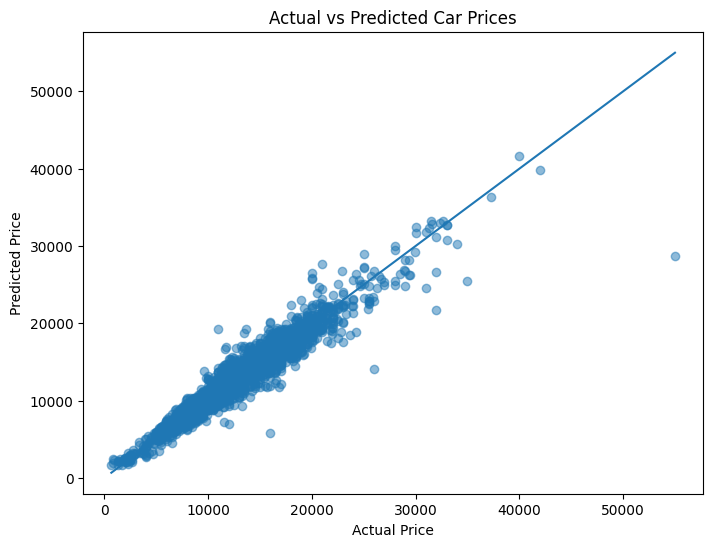

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, final_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

# Feature Importance

In [51]:
feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    final_model
    .named_steps["model"]
    .feature_importances_
)

In [52]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
31,remainder__year,0.500798
35,remainder__engineSize,0.242232
34,remainder__mpg,0.064319
32,remainder__mileage,0.057315
13,cat__model_Kuga,0.032270
5,cat__model_Fiesta,0.020800
12,cat__model_Ka+,0.018308
15,cat__model_Mustang,0.016786
3,cat__model_Edge,0.009810
33,remainder__tax,0.005282


In [ ]:
top_features = feature_importance.head(10).copy()

top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("remainder__", "", regex=False)
    .str.replace("cat__model_", "Model: ", regex=False)
    .str.replace("cat__transmission_", "Transmission: ", regex=False)
    .str.replace("cat__fuelType_", "Fuel: ", regex=False)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

# Testing a new car

In [53]:
new_car = pd.DataFrame({
    "model": ["Fiesta"],
    "year": [2019],
    "transmission": ["Manual"],
    "mileage": [25000],
    "fuelType": ["Petrol"],
    "tax": [145],
    "mpg": [55],
    "engineSize": [1.0]
})

predicted_price = final_model.predict(new_car)

print("Predicted Price: £", round(predicted_price[0], 2))

Predicted Price: £ 13718.59


# Prediction Function

In [54]:
def predict_car_price(
    model_name,
    year,
    transmission,
    mileage,
    fuel_type,
    tax,
    mpg,
    engine_size
):

    new_car = pd.DataFrame({
        "model": [model_name],
        "year": [year],
        "transmission": [transmission],
        "mileage": [mileage],
        "fuelType": [fuel_type],
        "tax": [tax],
        "mpg": [mpg],
        "engineSize": [engine_size]
    })

    predicted_price = final_model.predict(new_car)

    return round(predicted_price[0], 2)

In [55]:
def get_valid_input(prompt, min_value, max_value, data_type):
    while True:
        try:
            value = data_type(input(prompt))

            if min_value <= value <= max_value:
                return value

            print(f"Please enter a value between {min_value} and {max_value}.")

        except ValueError:
            print("Please enter a valid number.")

In [56]:
def get_valid_category(prompt, valid_options):
    while True:
        value = input(prompt).strip()

        if value in valid_options:
            return value

        print("Invalid choice. Please choose from:")
        print(", ".join(valid_options))

In [57]:
models = sorted(df["model"].unique())
transmissions = sorted(df["transmission"].unique())
fuel_types = sorted(df["fuelType"].unique())

# Save the final model

In [58]:
joblib.dump(final_model, "ford_car_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [63]:
print(os.path.exists("ford_car_price_model.pkl"))

True


# Load and Test the model

In [64]:
loaded_model = joblib.load("ford_car_price_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [65]:
price = loaded_model.predict(pd.DataFrame({
    "model": ["Focus"],
    "year": [2018],
    "transmission": ["Manual"],
    "mileage": [30000],
    "fuelType": ["Diesel"],
    "tax": [150],
    "mpg": [55],
    "engineSize": [1.5]
}))

print("Predicted Price: £", round(price[0], 2))

Predicted Price: £ 12218.55
